<a href="https://colab.research.google.com/github/ydv-prince/Machine-Learning/blob/main/1_simple_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Simple Linear Regression - 1**

In [244]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [245]:
# Reading the data
# Here we are loading the data from scikit learn

from sklearn.datasets import load_diabetes

In [246]:
diabetes = load_diabetes()

In [247]:
diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [248]:
#Problem statement: To predict disease progression one year after baseline provided 10 features
#in one year how the sugar level has changed

In [249]:
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [250]:
diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [251]:
diabetes.data

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]])

In [252]:
diabetes.target

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59., 104., 182.,
       128.,  52.,  37., 170., 170.,  61., 144.,  52., 128.,  71., 163.,
       150.,  97., 160., 178.,  48., 270., 202., 111.,  85.,  42., 170.,
       200., 252., 113., 143.,  51.,  52., 210.,  65., 141.,  55., 134.,
        42., 111.,  98., 164.,  48.,  96.,  90., 162., 150., 279.,  92.,
        83., 128., 102., 302., 198.,  95.,  53., 134., 144., 232.,  81.,
       104.,  59., 246., 297., 258., 229., 275., 281., 179., 200., 200.,
       173., 180.,  84., 121., 161.,  99., 109., 115., 268., 274., 158.,
       107.,  83., 103., 272.,  85., 280., 336., 281., 118., 317., 235.,
        60., 174., 259., 178., 128.,  96., 126., 28

In [253]:
diabetes.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [254]:
data = pd.DataFrame(diabetes.data, columns = diabetes.feature_names)

In [255]:
data

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


In [256]:
data.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [257]:
data['target'] = diabetes.target

In [258]:
data

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [259]:
# EDA, Data preprocessing, Data cleaning, Feature Engineering

In [260]:
x = data['bmi']
y = data['target']

In [261]:
x

,bmi
0,0.061696
1,-0.051474
2,0.044451
3,-0.011595
4,-0.036385
...,...
437,0.019662
438,-0.015906
439,-0.015906
440,0.039062


In [262]:
y

,target
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0
...,...
437,178.0
438,104.0
439,132.0
440,220.0


In [263]:
from sklearn.model_selection import train_test_split

In [264]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state= 2)
# random state when fixed it helps us to reproduce the same result again and again

In [265]:
x_train

,bmi
70,-0.069797
37,0.011039
170,-0.020218
400,0.045529
286,-0.054707
...,...
299,-0.013751
22,-0.004050
72,-0.004050
15,-0.018062


In [266]:
x_train.shape

(353,)

In [267]:
x_test.shape

(89,)

In [268]:
353 + 89

442

In [269]:
y_train.shape

(353,)

In [270]:
y_test.shape

(89,)

In [271]:
# Scaling(Optional)

In [272]:
# Model training

from sklearn.linear_model import LinearRegression

In [273]:
model = LinearRegression()

In [274]:
model

LinearRegression()

In [275]:
x_train

,bmi
70,-0.069797
37,0.011039
170,-0.020218
400,0.045529
286,-0.054707
...,...
299,-0.013751
22,-0.004050
72,-0.004050
15,-0.018062


In [276]:
y_train

,target
70,48.0
37,276.0
170,47.0
400,175.0
286,60.0
...,...
299,83.0
22,68.0
72,202.0
15,171.0


In [277]:
x_train

,bmi
70,-0.069797
37,0.011039
170,-0.020218
400,0.045529
286,-0.054707
...,...
299,-0.013751
22,-0.004050
72,-0.004050
15,-0.018062


In [279]:
# Training of model
model.fit(x_train, y_train)
# At the backend it will use the gradient descent to give the optimal coefficient

ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

In [280]:
x_train = x_train.values.reshape(-1,1)

In [281]:
model.fit(x_train, y_train)

LinearRegression()

In [282]:
model.coef_

array([974.48209999])

In [283]:
model.intercept_

np.float64(152.45404935855575)

In [284]:
y_pred = model.predict(x_test)

ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

In [285]:
x_test = x_test.values.reshape(-1,1)

In [286]:
y_pred = model.predict(x_test)

In [287]:
y_pred

array([155.8592353 , 228.33052685, 138.00398955, 105.44442379,
       219.92805826, 274.54410406,  94.94133806,  97.0419552 ,
       120.14874381, 210.4752811 , 153.75861815, 134.85306384,
       182.11694963, 151.65800101, 259.83978404, 121.19905238,
       190.51941821,  94.94133806, 127.50090382, 136.95368098,
       209.42497253, 222.02867541, 113.84689237, 164.26170388,
       132.75244669, 198.9218868 , 223.07898398, 128.5512124 ,
       113.84689237, 214.67651539, 235.68268686,  87.58917804,
        84.43825232, 120.14874381, 154.80892673, 161.11077816,
       171.6138639 , 168.46293818, 124.3499781 , 131.70213812,
       205.22373824, 128.5512124 , 206.27404681, 128.5512124 ,
       195.77096108, 140.1046067 , 173.71448104, 212.57589825,
       107.54504093, 159.01016102, 211.52558968, 205.22373824,
       156.90954387, 128.5512124 , 174.76478961, 122.24936096,
       114.89720095, 104.39411521, 136.95368098, 187.36849249,
       128.5512124 , 192.62003536, 144.30584099, 194.72

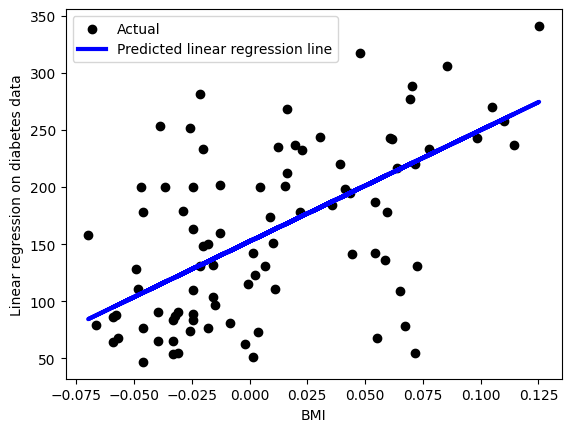

In [288]:
# Visualize the result

plt.scatter(x_test, y_test, color = 'black', label = 'Actual')
plt.plot(x_test, y_pred, color = 'blue', linewidth = 3, label = 'Predicted linear regression line')
plt.xlabel('BMI')
plt.ylabel('Linear regression on diabetes data')
plt.legend()
plt.show()

In [289]:
# Model Evaluation

from sklearn.metrics import mean_squared_error
mean_squared_error(y_test, y_pred)

3898.258609540553

# **Simple Linear Regression - 2**

In [290]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [355]:
# url = "https://drive.google.com/uc?export=download&id=1tEqoaik1z0VqkxeAThM_HXYh7cXC1jXW"

In [291]:
df = pd.read_csv('height-weight.csv')

In [292]:
df

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160
5,78,162
6,80,163
7,90,175
8,95,182
9,78,170


In [293]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


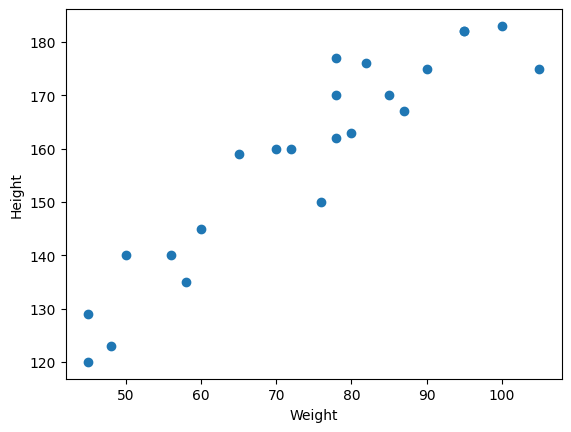

In [294]:
plt.scatter(df.Weight, df.Height)
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

In [295]:
# Problem statement >> I want to predict height based on weight

In [296]:
# Divide the data into x and y

x = df[["Weight"]]
y = df['Height']

In [297]:
x

,Weight
0,45
1,58
2,48
3,60
4,70
5,78
6,80
7,90
8,95
9,78


In [298]:
y

,Height
0,120
1,135
2,123
3,145
4,160
5,162
6,163
7,175
8,182
9,170


In [299]:
# Train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.25, random_state= 1)

In [300]:
x_train

,Weight
10,82
4,70
2,48
18,76
6,80
7,90
1,58
14,85
0,45
15,78


In [301]:
x_test

,Weight
20,45
17,65
3,60
13,100
19,87
16,50


In [302]:
y_train

,Height
10,176
4,160
2,123
18,150
6,163
7,175
1,135
14,170
0,120
15,177


In [303]:
y_test

,Height
20,129
17,159
3,145
13,183
19,167
16,140


In [304]:
x_train.shape

(17, 1)

In [305]:
x_test.shape

(6, 1)

In [306]:
y_train.shape

(17,)

In [307]:
y_test.shape

(6,)

In [308]:
# Scaling(Optional) >> Standardization >> fit_transform on train data & transform on test data
# if you use fit on test data, (that is wrong) you are doing data leakage , avoid it
# most of the ML model StandardScaler is used as it deals with normal distribution

In [309]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [310]:
scaler

StandardScaler()

In [311]:
x_train

,Weight
10,82
4,70
2,48
18,76
6,80
7,90
1,58
14,85
0,45
15,78


In [312]:
# Scaling should be done always after train test split
# target variables not be scaled
# avoid saling categorical features

x_train = scaler.fit_transform(x_train) # For train data use fit_transform
x_test = scaler.transform(x_test) # for test data use transform

In [313]:
x_train

array([[ 0.37554243],
       [-0.36825034],
       [-1.73187043],
       [ 0.00364604],
       [ 0.25157697],
       [ 0.87140428],
       [-1.11204312],
       [ 0.56149062],
       [-1.91781863],
       [ 0.12761151],
       [-0.24428488],
       [-1.23600858],
       [ 0.12761151],
       [ 1.18131794],
       [ 1.80114525],
       [ 1.18131794],
       [ 0.12761151]])

In [314]:
x_test

array([[-1.91781863],
       [-0.678164  ],
       [-0.98807766],
       [ 1.49123159],
       [ 0.68545609],
       [-1.60790497]])

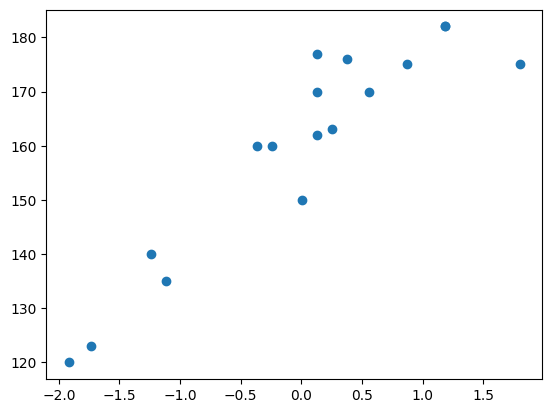

In [315]:
# Scaling is optional >> Because it doesn't affect the distribution of the data

plt.scatter(x_train, y_train)

In [316]:
#model training
from sklearn.linear_model import LinearRegression

#linear regression parameters
#fit_intercept >> The best fit line will have intercept, by default it is true
#copy_X >> copy the original X_train and then build the model, it will not modify the original data
#n_jobs >>-1 means using all processors.
#positive>> When set to True, forces the coefficients to be positive.

#fit>> train the model
#predict>> test the model

#after building the model, you have attributes of the model
#coef_
#intercept

In [317]:
regressor = LinearRegression()

In [318]:
regressor

LinearRegression()

In [319]:
regressor.fit(x_train, y_train)

LinearRegression()

In [320]:
regressor

LinearRegression()

In [321]:
regressor.coef_

array([17.7307072])

In [322]:
regressor.intercept_

np.float64(160.0)

In [323]:
print(f"The slope of coeff of model is: {regressor.coef_}")
print(f"The intercept of the model is: {regressor.intercept_}")

The slope of coeff of model is: [17.7307072]
The intercept of the model is: 160.0


In [324]:
# Prediction on train data
#interpretation of coef>> one unit increase in weight, on average the height increase by 17.73 units
#predicted height(y) on x_train = 160 + 17.73 * (x_train)
#predicted height(y) on x_test = 160 + 17.73 * (x_test)

In [325]:
# Prediction on train data
regressor.predict(x_train)

array([166.65863288, 153.47066096, 129.29271243, 160.06464692,
       164.46063756, 175.45061417, 140.28268904, 169.95562586,
       125.99571945, 162.26264224, 155.66865628, 138.08469371,
       162.26264224, 180.94560247, 191.93557907, 180.94560247,
       162.26264224])

In [326]:
y_pred = regressor.predict(x_train)

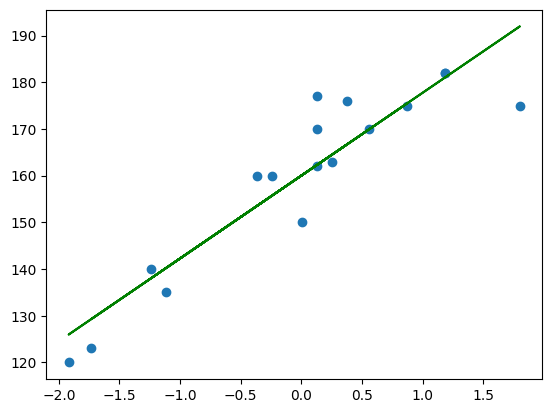

In [327]:
plt.scatter(x_train, y_train)
plt.plot(x_train, y_pred, color = 'green')
plt.show()

In [328]:
# Prediction on test data
y_pred_test = regressor.predict(x_test)

In [329]:
y_pred_test

array([125.99571945, 147.97567266, 142.48068436, 186.44059077,
       172.15362118, 131.49070775])

In [330]:
y_pred_test, y_test

(array([125.99571945, 147.97567266, 142.48068436, 186.44059077,
        172.15362118, 131.49070775]),
 20    129
 17    159
 3     145
 13    183
 19    167
 16    140
 Name: Height, dtype: int64)

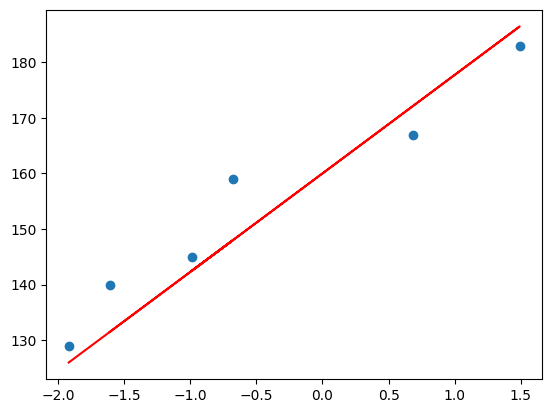

In [331]:
plt.scatter(x_test, y_test)
plt.plot(x_test, y_pred_test, color = 'red')

In [332]:
# Performance metrics

In [333]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [334]:
mean_absolute_error(y_test, y_pred_test)

5.608571289304838

In [335]:
mean_squared_error(y_test, y_pred_test)

41.285662830455514

In [336]:
r2_score(y_test, y_pred_test)   # 1- SSR/SST

0.8721036174256606

In [337]:
# adjusted rsquare
# adjusted R2 = [1 - (1 - rsquare) * n-1/(n-k-1)] >> n is no of observation and k is no of predictor variables

In [338]:
x_test.shape

(6, 1)

In [339]:
x_test.shape[0]

6

In [340]:
x_test.shape[1]

1

In [341]:
rsq = r2_score(y_test,y_pred_test) #rsquare = 1-SSR/SST
rsq

0.8721036174256606

In [342]:
1-(1-rsq) * (len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)   # adjusted rsquare will be lesser than r square

0.8401295217820757

In [343]:
# assumption
# X-y should have linear relationship
# Observation should have no relation
# error should have constant variation
# error should be normally distributed
# features among themself should be least related

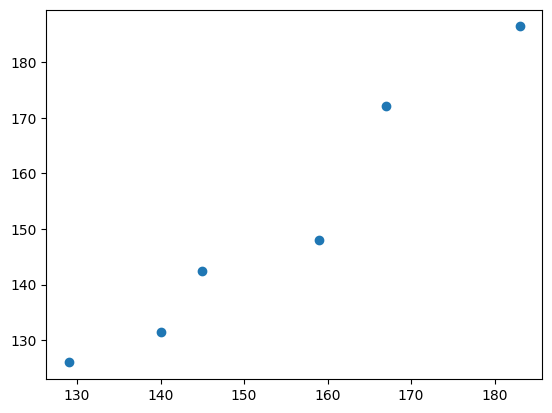

In [344]:
plt.scatter(y_test, y_pred_test)    # to check if y_test & its prediction aligns
plt.show()

In [345]:
error = y_test - y_pred_test

In [346]:
error

,Height
20,3.004281
17,11.024327
3,2.519316
13,-3.440591
19,-5.153621
16,8.509292


In [347]:
import seaborn as sns

<Axes: xlabel='Height', ylabel='Density'>

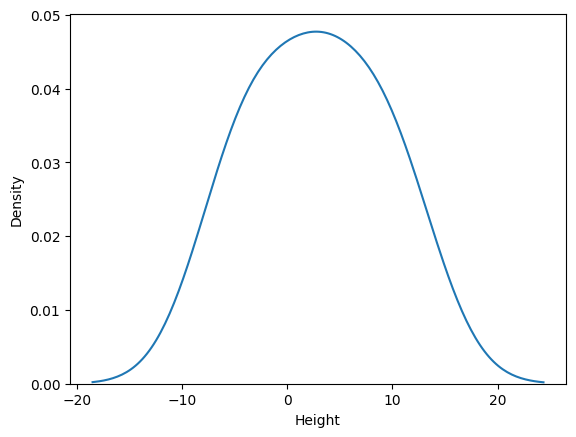

In [348]:
sns.kdeplot(error)    # approximately a normal distribution

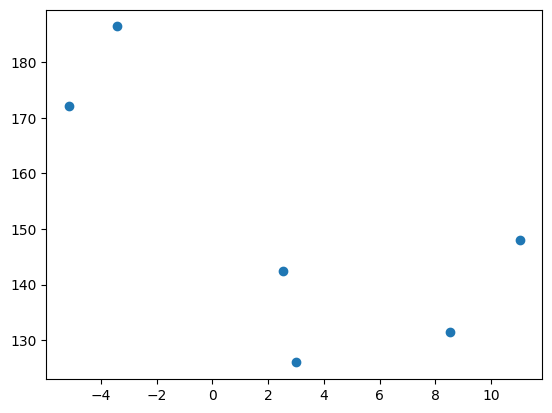

In [349]:
# to check constant variance
plt.scatter(error, y_pred_test)